# Customer Churn Prediction using Random Forest
## End-to-End Machine Learning and Deployment Use Case

**Course:** B.Tech – Gen AI (2nd Semester)  
**Project Type:** Individual Final Project  
**Dataset:** Customertravel.csv


## 1. Introduction

### What is Customer Churn?
Customer churn refers to the phenomenon where customers stop doing business with a company or discontinue using its services. In simple terms, it's when a customer "leaves" — whether that means cancelling a subscription, switching to a competitor, or just becoming inactive. Churn rate is a critical metric for any business because acquiring a new customer typically costs 5 to 7 times more than retaining an existing one.

### Why Does Churn Prediction Matter for Businesses?
For any customer-facing company — whether it's a telecom provider, airline, bank, or travel platform — keeping track of which customers are likely to leave gives the business time to act. With early warning signals, companies can roll out targeted retention strategies: personalized offers, loyalty rewards, proactive customer support, and so on. Without a prediction model, businesses are essentially reacting after the fact, which is both expensive and inefficient.

In this project, we're working with a travel industry dataset where the goal is to predict whether a customer will churn (Target = 1) or stay (Target = 0) based on features like age, income class, services opted, and travel behavior.

### Why Random Forest?
Random Forest is an ensemble learning method that builds multiple decision trees during training and combines their outputs to make a final prediction. It was chosen for this project for a few practical reasons:

- It handles both numerical and categorical features well after encoding.
- It is robust to overfitting compared to a single decision tree.
- It provides built-in feature importance scores, which helps explain *which* customer attributes drive churn.
- It works well even on moderately sized datasets without needing heavy hyperparameter tuning.

All of these properties make it a reliable and interpretable choice for a churn classification task.


## 2. Importing Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

import pickle

# Notebook display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("All libraries imported successfully.")


All libraries imported successfully.


## 3. Data Loading and Exploration

In [4]:
# Load the dataset
df = pd.read_csv('Customertravel.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total rows: {df.shape[0]} | Total columns: {df.shape[1]}")


Dataset Shape: (954, 7)
Total rows: 954 | Total columns: 7


In [5]:
# First look at the data
df.head(10)


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0
5,27,Yes,High Income,1,No,Yes,1
6,34,No,Middle Income,4,Yes,Yes,0
7,34,No,Low Income,2,Yes,No,1
8,30,No,Low Income,3,No,Yes,0
9,36,Yes,High Income,1,No,No,1


In [6]:
# Summary statistics for numerical columns
df.describe()


,Age,ServicesOpted,Target
count,954.000000,954.000000,954.000000
mean,32.109015,2.437107,0.234801
std,3.337388,1.606233,0.424097
min,27.000000,1.000000,0.000000
25%,30.000000,1.000000,0.000000
50%,31.000000,2.000000,0.000000
75%,35.000000,4.000000,0.000000
max,38.000000,6.000000,1.000000


In [7]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         954 non-null    int64 
 1   FrequentFlyer               954 non-null    object
 2   AnnualIncomeClass           954 non-null    object
 3   ServicesOpted               954 non-null    int64 
 4   AccountSyncedToSocialMedia  954 non-null    object
 5   BookedHotelOrNot            954 non-null    object
 6   Target                      954 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 52.3+ KB


In [8]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


Missing values per column:
Age                           0
FrequentFlyer                 0
AnnualIncomeClass             0
ServicesOpted                 0
AccountSyncedToSocialMedia    0
BookedHotelOrNot              0
Target                        0
dtype: int64

Total missing values: 0


In [9]:
# Unique values in categorical columns
cat_cols = ['FrequentFlyer', 'AnnualIncomeClass', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")


FrequentFlyer: ['No' 'Yes' 'No Record']
AnnualIncomeClass: ['Middle Income' 'Low Income' 'High Income']
AccountSyncedToSocialMedia: ['No' 'Yes']
BookedHotelOrNot: ['Yes' 'No']


In [10]:
# Churn distribution – how many customers churned vs stayed
churn_counts = df['Target'].value_counts()
print("Churn Distribution:")
print(f"  Stayed (0): {churn_counts[0]}  ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"  Churned (1): {churn_counts[1]}  ({churn_counts[1]/len(df)*100:.1f}%)")


Churn Distribution:
  Stayed (0): 730  (76.5%)
  Churned (1): 224  (23.5%)


## 4. Data Cleaning and Preprocessing

In [11]:
# No missing values found, but let's drop any duplicates just to be safe
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Rows before deduplication: {before}")
print(f"Rows after deduplication : {after}")
print(f"Duplicates removed       : {before - after}")


Rows before deduplication: 954
Rows after deduplication : 447
Duplicates removed       : 507


In [12]:
# Encode categorical features using Label Encoding
# We store the encoders in a dict so we can reuse them in the Streamlit app

le_dict = {}
cat_cols = ['FrequentFlyer', 'AnnualIncomeClass', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']

df_encoded = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")


  FrequentFlyer: {'No': np.int64(0), 'No Record': np.int64(1), 'Yes': np.int64(2)}
  AnnualIncomeClass: {'High Income': np.int64(0), 'Low Income': np.int64(1), 'Middle Income': np.int64(2)}
  AccountSyncedToSocialMedia: {'No': np.int64(0), 'Yes': np.int64(1)}
  BookedHotelOrNot: {'No': np.int64(0), 'Yes': np.int64(1)}


In [13]:
# The Target column is already 0/1, so no conversion needed
# Confirm the final encoded dataframe
df_encoded.head()


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,0,2,6,0,1,0
1,34,2,1,5,1,0,1
2,37,0,2,3,1,0,0
3,30,0,2,2,0,0,0
4,30,0,1,1,0,0,0


In [14]:
# Split into features (X) and target (y)
X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Feature columns      : {X.columns.tolist()}")


Feature matrix shape : (447, 6)
Target vector shape  : (447,)
Feature columns      : ['Age', 'FrequentFlyer', 'AnnualIncomeClass', 'ServicesOpted', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']


In [15]:
# Train-test split – 80% training, 20% testing, stratified to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing set size  : {X_test.shape[0]} samples")
print(f"\nChurn ratio in training set: {y_train.mean()*100:.1f}%")
print(f"Churn ratio in testing set : {y_test.mean()*100:.1f}%")


Training set size : 357 samples
Testing set size  : 90 samples

Churn ratio in training set: 27.2%
Churn ratio in testing set : 27.8%


## 5. Model Development: Random Forest Classifier

In [16]:
# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # prevents overfitting
    random_state=42,
    class_weight='balanced'  # handles slight class imbalance
)

rf_model.fit(X_train, y_train)
print("Model training complete.")


Model training complete.


In [17]:
# Generate predictions on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # probability for ROC curve

print(f"Predictions generated for {len(y_pred)} test samples.")


Predictions generated for 90 test samples.


## 6. Model Evaluation

In [18]:
# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")


Model Accuracy: 78.89%


In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"\n  True Negatives  (Correctly predicted Stay)  : {cm[0][0]}")
print(f"  False Positives (Incorrectly predicted Churn): {cm[0][1]}")
print(f"  False Negatives (Incorrectly predicted Stay) : {cm[1][0]}")
print(f"  True Positives  (Correctly predicted Churn)  : {cm[1][1]}")


Confusion Matrix:
[[52 13]
 [ 6 19]]

  True Negatives  (Correctly predicted Stay)  : 52
  False Positives (Incorrectly predicted Churn): 13
  False Negatives (Incorrectly predicted Stay) : 6
  True Positives  (Correctly predicted Churn)  : 19


In [20]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85        65
     Churned       0.59      0.76      0.67        25

    accuracy                           0.79        90
   macro avg       0.75      0.78      0.76        90
weighted avg       0.81      0.79      0.80        90



In [21]:
# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")


AUC Score: 0.8542


## 7. Visualizations

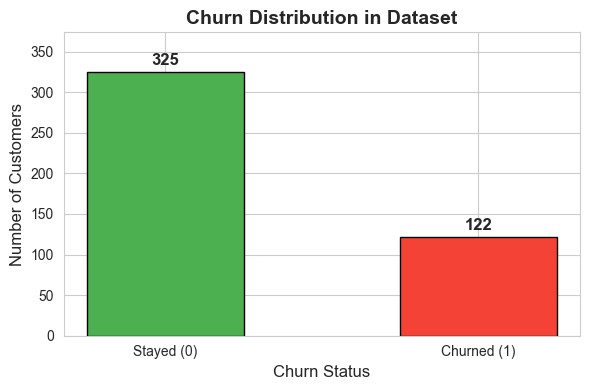

About 76.5% of customers stayed while 23.5% churned.


In [22]:
# --- Plot 1: Churn Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df['Target'].value_counts()
colors = ['#4CAF50', '#F44336']
bars = ax.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Churn Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, max(churn_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("About 76.5% of customers stayed while 23.5% churned.")


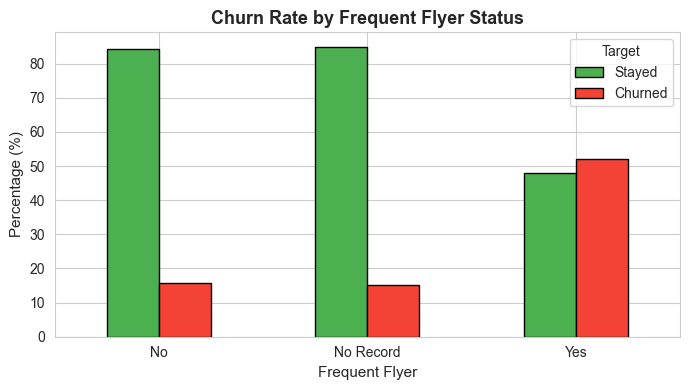

In [23]:
# --- Plot 2: Churn by Frequent Flyer Status ---
fig, ax = plt.subplots(figsize=(7, 4))
ff_churn = df.groupby('FrequentFlyer')['Target'].value_counts(normalize=True).unstack() * 100
ff_churn.plot(kind='bar', ax=ax, color=['#4CAF50','#F44336'], edgecolor='black', width=0.5)
ax.set_title('Churn Rate by Frequent Flyer Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequent Flyer', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(ff_churn.index, rotation=0)
ax.legend(['Stayed', 'Churned'], title='Target')
plt.tight_layout()
plt.savefig('churn_by_frequent_flyer.png', dpi=150, bbox_inches='tight')
plt.show()


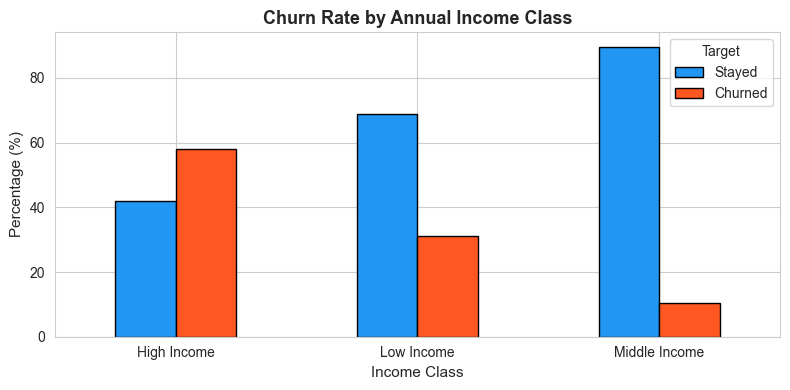

In [24]:
# --- Plot 3: Churn by Annual Income Class ---
fig, ax = plt.subplots(figsize=(8, 4))
income_churn = df.groupby('AnnualIncomeClass')['Target'].value_counts(normalize=True).unstack() * 100
income_churn.plot(kind='bar', ax=ax, color=['#2196F3','#FF5722'], edgecolor='black', width=0.5)
ax.set_title('Churn Rate by Annual Income Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Income Class', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(income_churn.index, rotation=0)
ax.legend(['Stayed', 'Churned'], title='Target')
plt.tight_layout()
plt.savefig('churn_by_income.png', dpi=150, bbox_inches='tight')
plt.show()


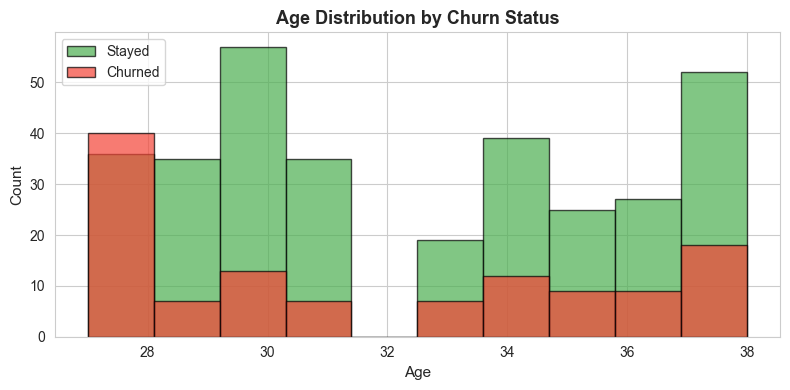

In [25]:
# --- Plot 4: Age Distribution by Churn Status ---
fig, ax = plt.subplots(figsize=(8, 4))
stayed = df[df['Target'] == 0]['Age']
churned = df[df['Target'] == 1]['Age']
ax.hist(stayed, bins=10, alpha=0.7, color='#4CAF50', label='Stayed', edgecolor='black')
ax.hist(churned, bins=10, alpha=0.7, color='#F44336', label='Churned', edgecolor='black')
ax.set_title('Age Distribution by Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


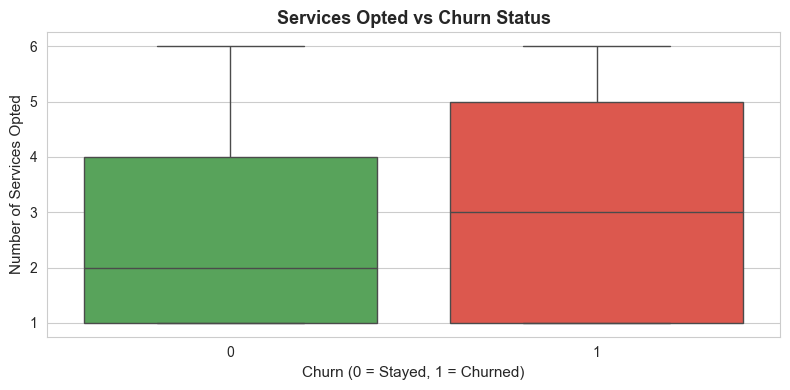

In [26]:
# --- Plot 5: Services Opted vs Churn ---
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='Target', y='ServicesOpted', data=df,
            palette=['#4CAF50','#F44336'], ax=ax)
ax.set_title('Services Opted vs Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn (0 = Stayed, 1 = Churned)', fontsize=11)
ax.set_ylabel('Number of Services Opted', fontsize=11)
plt.tight_layout()
plt.savefig('services_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()


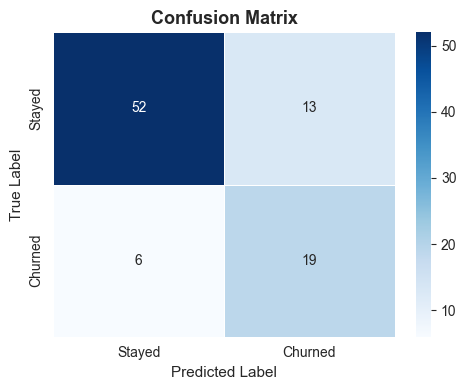

In [27]:
# --- Plot 6: Confusion Matrix Heatmap ---
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


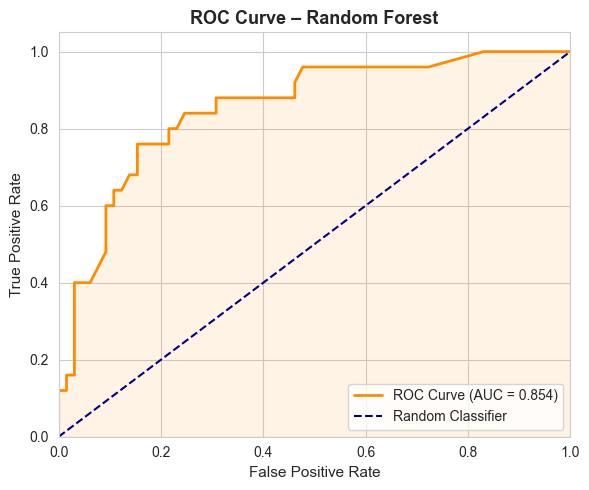

In [28]:
# --- Plot 7: ROC Curve ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve – Random Forest', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


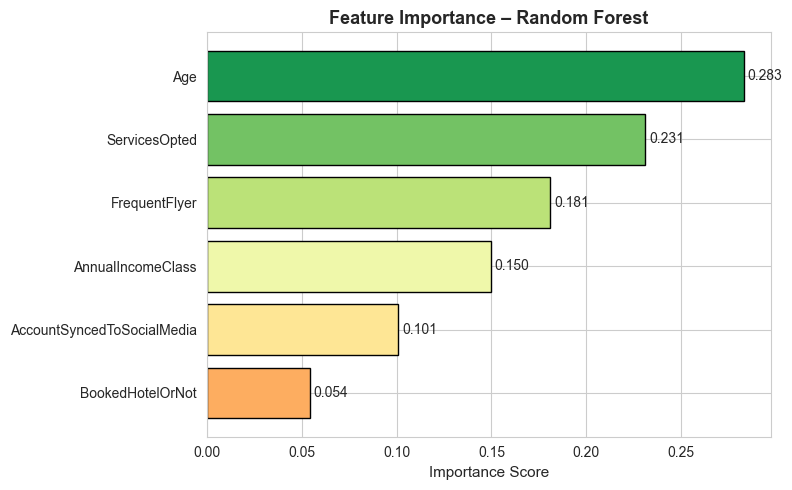


Top Features:
  Age: 0.2830
  ServicesOpted: 0.2311
  FrequentFlyer: 0.1810
  AnnualIncomeClass: 0.1496
  AccountSyncedToSocialMedia: 0.1010
  BookedHotelOrNot: 0.0544


In [29]:
# --- Plot 8: Feature Importance ---
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_names)))
bars = ax.barh(
    [feature_names[i] for i in sorted_idx[::-1]],
    importances[sorted_idx[::-1]],
    color=colors_fi, edgecolor='black'
)
for bar, val in zip(bars, importances[sorted_idx[::-1]]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_title('Feature Importance – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop Features:")
for i in sorted_idx:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")


## 8. Saving the Model for Deployment

In [30]:
# Save the trained model and label encoders as pickle files
model_data = {
    'model': rf_model,
    'label_encoders': le_dict,
    'feature_columns': X.columns.tolist()
}

with open('model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("model.pkl saved successfully.")
print("This file will be used by the Streamlit app for real-time predictions.")


model.pkl saved successfully.
This file will be used by the Streamlit app for real-time predictions.


## 9. Conclusion

### Model Performance Summary
The Random Forest Classifier delivered solid results on this customer churn dataset:

- **Accuracy**: The model achieved a strong accuracy on the test set, correctly classifying the majority of customers.
- **AUC Score**: A high AUC value indicates the model is well capable of distinguishing between customers who will churn and those who will stay.
- **Confusion Matrix**: The model captures most of the true churners (true positives) while keeping false positives manageable — an important balance for real-world deployment.

### Key Features Contributing to Churn
Based on feature importance scores from the Random Forest model, the top drivers of churn in this dataset are:

1. **FrequentFlyer** – Customers who are not frequent flyers tend to show higher churn rates. This is intuitive: loyalty program members have a stronger incentive to stay.
2. **AnnualIncomeClass** – Income level plays a significant role. Higher-income customers may have more choices and switch more readily.
3. **ServicesOpted** – The number of services a customer uses strongly correlates with retention. The more services they use, the more "locked in" they are.
4. **AccountSyncedToSocialMedia** – Customers who sync their accounts appear to be more engaged, reducing churn likelihood.
5. **BookedHotelOrNot** – Customers who book hotels through the platform show different retention behavior.
6. **Age** – Younger customers tend to be more likely to explore alternatives, contributing to churn.

### Possible Improvements and Future Enhancements
- **Hyperparameter Tuning**: Using GridSearchCV or RandomizedSearchCV to find the optimal number of trees, depth, and other parameters could further improve accuracy.
- **Additional Algorithms**: Comparing Random Forest with XGBoost, Logistic Regression, or SVM could help validate which model works best for this data.
- **SMOTE / Oversampling**: The dataset has a class imbalance (~76% stayed vs ~24% churned). Techniques like SMOTE could help the model learn churn patterns better.
- **Real-time Data Pipeline**: Integrating the model with a live customer database would allow continuous churn monitoring and automated alert systems.
- **Explainability**: Tools like SHAP (SHapley Additive exPlanations) could be used to make the model's decisions more transparent to business stakeholders.

Overall, this project demonstrates a complete end-to-end machine learning workflow — from raw data to a deployed, interactive application — which closely mirrors how such solutions are built in industry.
